# Clasificación de hojas con K-Means

Pipeline:
1. Carga de `HOJASTRAINING.csv` (entreno), `Val.csv` (validación) y `HOJASCLASIFICAR.xlsx` (test).
2. Limpieza (separador `;`, decimal `,`, normalización de columnas) y escalado robusto.
3. **K-Means con K=4** sobre `n_vertices`, `largo`, `ancho`.
4. Asignación de cada cluster → clase real por voto mayoritario en training.
5. Predicción en validación y test; **pseudo-probabilidades** a partir de las distancias a centroides (softmax de −d).
6. Métricas: accuracy, precision/recall/F1, matriz de confusión, **ROC one-vs-rest** + AUC por clase y macro/micro.

K-Means no es nativamente supervisado, así que la calidad final depende mucho de que los clusters
geométricos coincidan con las clases. Es lo que vamos a medir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from scipy.optimize import linear_sum_assignment

plt.rcParams["figure.dpi"] = 110

OUT = Path("resultados_kmeans_hojas")
OUT.mkdir(exist_ok=True)
RNG = 42

## 1. Carga y limpieza

In [2]:
def _to_float(x):
    if isinstance(x, str):
        return float(x.replace(",", ".").strip())
    return float(x)

def load_dataset(path, kind):
    """Devuelve DataFrame normalizado con columnas: id, n_vertices, largo, ancho, clase."""
    if kind == "csv":
        df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
    elif kind == "xlsx":
        df = pd.read_excel(path)
    else:
        raise ValueError(kind)

    # Normalizar nombres de columna a minúsculas y mapear sinónimos
    df.columns = [c.strip().lower() for c in df.columns]
    rename = {"vertices": "n_vertices"}
    df = df.rename(columns=rename)

    for col in ["largo", "ancho", "n_vertices", "clase"]:
        df[col] = df[col].apply(_to_float)

    df["n_vertices"] = df["n_vertices"].astype(int)
    df["clase"] = df["clase"].astype(int)
    return df[["id", "n_vertices", "largo", "ancho", "clase"]]

df_train = load_dataset("HOJASTRAINING.csv", "csv")
df_val = load_dataset("Val.csv", "csv")
df_test = load_dataset("HOJASCLASIFICAR.xlsx", "xlsx")

print(f"train: {df_train.shape},  val: {df_val.shape},  test: {df_test.shape}")
print("\nDistribución de clases:")
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"  {name:5}: {df['clase'].value_counts().sort_index().to_dict()}")

df_train.head()

train: (39, 5),  val: (25, 5),  test: (50, 5)

Distribución de clases:
  train: {0: 18, 1: 8, 2: 12, 3: 1}
  val  : {0: 17, 1: 1, 2: 3, 3: 4}
  test : {0: 26, 1: 7, 2: 15, 3: 2}


,id,n_vertices,largo,ancho,clase
0,J1,1,14.0,3.0,0
1,J2,1,10.0,4.0,0
2,J3,5,4.5,5.0,2
3,J4,1,8.0,4.0,0
4,J5,1,10.0,6.0,0


## 2. Features + escalado

In [3]:
FEATURES = ["n_vertices", "largo", "ancho"]

X_train = df_train[FEATURES].to_numpy(dtype=float)
y_train = df_train["clase"].to_numpy()
X_val   = df_val[FEATURES].to_numpy(dtype=float)
y_val   = df_val["clase"].to_numpy()
X_test  = df_test[FEATURES].to_numpy(dtype=float)
y_test  = df_test["clase"].to_numpy()

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_val   = scaler.transform(X_val)
Xs_test  = scaler.transform(X_test)

classes = sorted(np.unique(np.concatenate([y_train, y_val, y_test])))
K = len(classes)
print("Clases:", classes, "  →  K =", K)

Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]   →  K = 4


## 3. Entrenamiento K-Means

Con `K = 4` (= número de clases). Inicialización `k-means++` y `n_init=50` para estabilidad sobre
este dataset pequeño.

In [4]:
km = KMeans(n_clusters=K, n_init=50, random_state=RNG)
km.fit(Xs_train)
print(f"inertia (training): {km.inertia_:.3f}")
print("centroides (escalados):\n", np.round(km.cluster_centers_, 3))

inertia (training): 26.305
centroides (escalados):
 [[-0.269 -0.651 -0.684]
 [-0.289  2.046  1.859]
 [ 4.162 -0.042 -0.846]
 [-0.147  0.305  0.518]]


## 4. Mapeo cluster → clase (asignación óptima)

Construyo una matriz `cluster × clase` con conteos en training y resuelvo el problema de
asignación con `linear_sum_assignment` (Hungarian) para maximizar coincidencias. Esto evita
que dos clusters mapeen a la misma clase.

In [5]:
def map_clusters_to_labels(cluster_ids, y_true, n_clusters, n_classes):
    M = np.zeros((n_clusters, n_classes), dtype=int)
    for c, y in zip(cluster_ids, y_true):
        M[c, y] += 1
    # Hungarian para maximizar (minimizamos el negativo)
    row_ind, col_ind = linear_sum_assignment(-M)
    mapping = dict(zip(row_ind, col_ind))
    return mapping, M

clusters_train = km.predict(Xs_train)
mapping, conf_clusters = map_clusters_to_labels(clusters_train, y_train, K, K)
print("Matriz cluster × clase (training):")
print(pd.DataFrame(conf_clusters, index=[f"cluster_{i}" for i in range(K)],
                   columns=[f"clase_{c}" for c in classes]))
print("\nMapeo aprendido (cluster → clase):", mapping)

Matriz cluster × clase (training):
           clase_0  clase_1  clase_2  clase_3
cluster_0       10        5        4        0
cluster_1        2        1        1        0
cluster_2        0        0        1        1
cluster_3        6        2        6        0

Mapeo aprendido (cluster → clase): {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(3), np.int64(3): np.int64(2)}


## 5. Predicciones y pseudo-probabilidades

K-Means no produce probabilidades. Genero **pseudo-probabilidades** desde la distancia a centroides:
$$
  p_k(x) = \frac{\exp(-d_k(x)/\tau)}{\sum_j \exp(-d_j(x)/\tau)},
$$
con $\tau$ = mediana de las distancias en training (escala adaptada al dataset). Luego se
agregan los $p_k$ sobre los clusters mapeados a cada clase.

In [6]:
def cluster_to_class_probs(X, kmeans, mapping, classes, tau):
    d = kmeans.transform(X)                      # (n, n_clusters), distancia a cada centroide
    p = np.exp(-d / tau)
    p = p / p.sum(axis=1, keepdims=True)         # softmax sobre clusters

    n = X.shape[0]; C = len(classes)
    P = np.zeros((n, C))
    for cluster_id, cls_id in mapping.items():
        idx = classes.index(cls_id)
        P[:, idx] += p[:, cluster_id]
    P = P / P.sum(axis=1, keepdims=True)         # normalizar por seguridad numérica
    return P

tau = float(np.median(km.transform(Xs_train)))
print(f"tau (escala de distancia) = {tau:.4f}")

def predict_set(X, y_true):
    clusters = km.predict(X)
    y_pred = np.array([mapping[c] for c in clusters])
    P = cluster_to_class_probs(X, km, mapping, classes, tau)
    return clusters, y_pred, P

clusters_val,   y_pred_val,   P_val   = predict_set(Xs_val,   y_val)
clusters_test,  y_pred_test,  P_test  = predict_set(Xs_test,  y_test)
clusters_tr,    y_pred_tr,    P_tr    = predict_set(Xs_train, y_train)

tau (escala de distancia) = 2.2808


## 6. Métricas globales

In [7]:
def report(name, y_true, y_pred, P, classes):
    acc = accuracy_score(y_true, y_pred)
    prf_macro = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prf_micro = precision_recall_fscore_support(y_true, y_pred, average="micro", zero_division=0)
    prf_w = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    # AUC one-vs-rest: solo clases presentes en y_true
    classes_present = sorted(np.unique(y_true))
    if len(classes_present) >= 2:
        idx_present = [classes.index(c) for c in classes_present]
        y_bin = label_binarize(y_true, classes=classes_present)
        if y_bin.shape[1] == 1:                  # solo 2 clases
            y_bin = np.hstack([1 - y_bin, y_bin])
        try:
            auc_macro = roc_auc_score(y_bin, P[:, idx_present], average="macro",
                                       multi_class="ovr")
            auc_weighted = roc_auc_score(y_bin, P[:, idx_present], average="weighted",
                                          multi_class="ovr")
        except ValueError:
            auc_macro = auc_weighted = np.nan
    else:
        auc_macro = auc_weighted = np.nan

    print(f"\n=== {name} ===")
    print(f"accuracy            : {acc:.4f}")
    print(f"precision/recall/F1 macro    : {prf_macro[0]:.3f} / {prf_macro[1]:.3f} / {prf_macro[2]:.3f}")
    print(f"precision/recall/F1 micro    : {prf_micro[0]:.3f} / {prf_micro[1]:.3f} / {prf_micro[2]:.3f}")
    print(f"precision/recall/F1 weighted : {prf_w[0]:.3f} / {prf_w[1]:.3f} / {prf_w[2]:.3f}")
    print(f"AUC macro (OvR)    : {auc_macro:.4f}")
    print(f"AUC weighted (OvR) : {auc_weighted:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return {
        "split": name, "n": len(y_true),
        "accuracy": acc,
        "precision_macro": prf_macro[0], "recall_macro": prf_macro[1], "f1_macro": prf_macro[2],
        "precision_weighted": prf_w[0], "recall_weighted": prf_w[1], "f1_weighted": prf_w[2],
        "auc_macro": auc_macro, "auc_weighted": auc_weighted,
    }

summary_rows = []
summary_rows.append(report("TRAIN", y_train, y_pred_tr,   P_tr,   classes))
summary_rows.append(report("VAL",   y_val,   y_pred_val,  P_val,  classes))
summary_rows.append(report("TEST",  y_test,  y_pred_test, P_test, classes))
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT / "metricas_globales.csv", index=False)
summary


=== TRAIN ===
accuracy            : 0.4615
precision/recall/F1 macro    : 0.426 / 0.545 / 0.459
precision/recall/F1 micro    : 0.462 / 0.462 / 0.462
precision/recall/F1 weighted : 0.439 / 0.462 / 0.443
AUC macro (OvR)    : 0.6756
AUC weighted (OvR) : 0.5939

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.56      0.54        18
           1       0.25      0.12      0.17         8
           2       0.43      0.50      0.46        12
           3       0.50      1.00      0.67         1

    accuracy                           0.46        39
   macro avg       0.43      0.55      0.46        39
weighted avg       0.44      0.46      0.44        39


=== VAL ===
accuracy            : 0.4800
precision/recall/F1 macro    : 0.507 / 0.457 / 0.417
precision/recall/F1 micro    : 0.480 / 0.480 / 0.480
precision/recall/F1 weighted : 0.773 / 0.480 / 0.548
AUC macro (OvR)    : 0.6328
AUC weighted (OvR) : 0.8073

Classification report:


              precision    recall  f1-score   support

           0       0.88      0.41      0.56        17
           1       0.00      0.00      0.00         1
           2       0.15      0.67      0.25         3
           3       1.00      0.75      0.86         4

    accuracy                           0.48        25
   macro avg       0.51      0.46      0.42        25
weighted avg       0.77      0.48      0.55        25


=== TEST ===
accuracy            : 0.4000
precision/recall/F1 macro    : 0.301 / 0.282 / 0.265
precision/recall/F1 micro    : 0.400 / 0.400 / 0.400
precision/recall/F1 weighted : 0.514 / 0.400 / 0.412
AUC macro (OvR)    : 0.6699
AUC weighted (OvR) : 0.6169

Classification report:


              precision    recall  f1-score   support

           0       0.77      0.38      0.51        26
           1       0.10      0.14      0.12         7
           2       0.33      0.60      0.43        15
           3       0.00      0.00      0.00         2

    accuracy                           0.40        50
   macro avg       0.30      0.28      0.26        50
weighted avg       0.51      0.40      0.41        50



,split,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro,auc_weighted
0,TRAIN,39,0.461538,0.426222,0.545139,0.458853,0.438886,0.461538,0.442774,0.675640,0.593941
1,VAL,25,0.480000,0.507212,0.457108,0.416786,0.773462,0.480000,0.547943,0.632799,0.807273
2,TEST,50,0.400000,0.300641,0.281868,0.264760,0.514000,0.400000,0.411709,0.669949,0.616882


## 7. Matrices de confusión

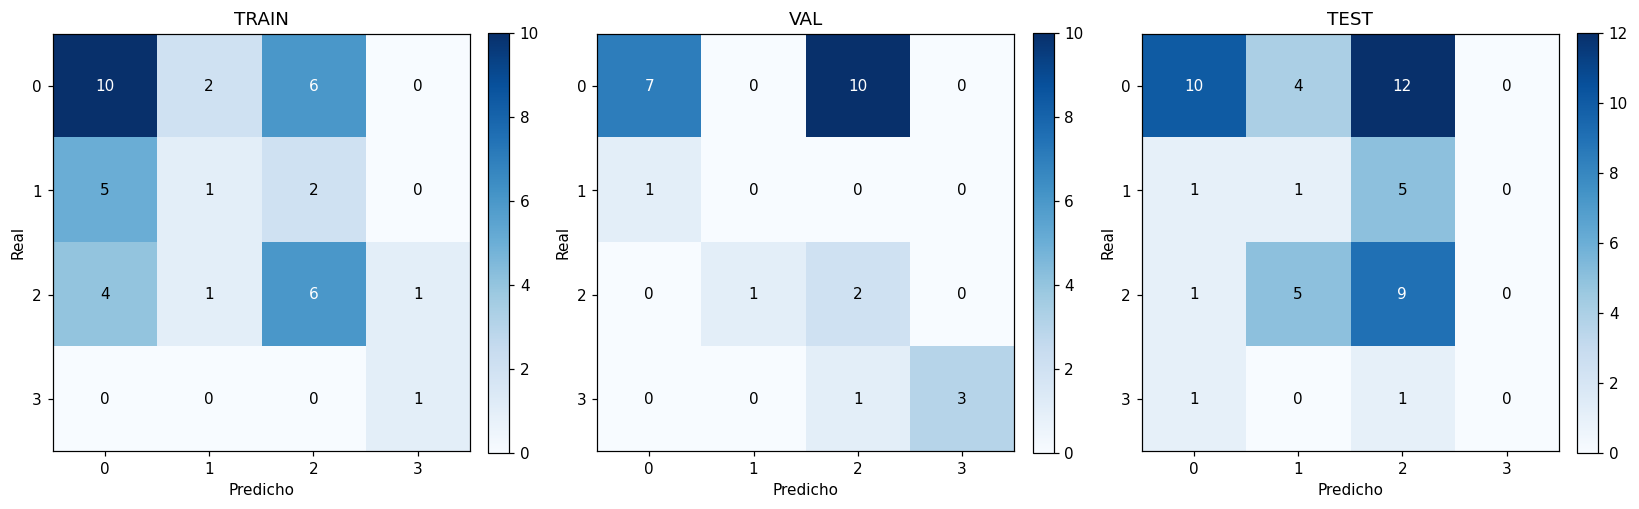

In [8]:
def plot_confusion(ax, y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            ax.text(j, i, str(v), ha="center", va="center",
                    color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_confusion(axes[0], y_train, y_pred_tr,   classes, "TRAIN")
plot_confusion(axes[1], y_val,   y_pred_val,  classes, "VAL")
plot_confusion(axes[2], y_test,  y_pred_test, classes, "TEST")
fig.tight_layout()
fig.savefig(OUT / "matrices_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Curvas ROC (one-vs-rest)

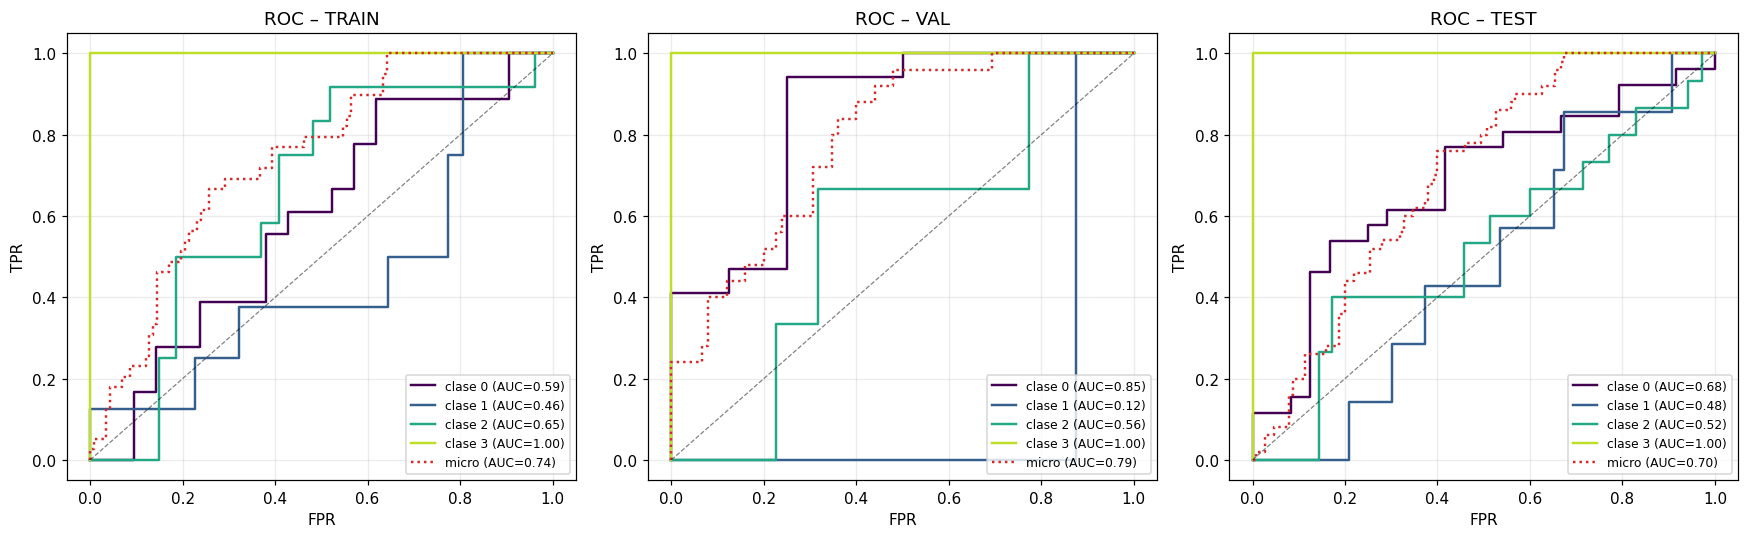

,train,val,test
0,0.593,0.846,0.679
1,0.456,0.125,0.478
2,0.654,0.561,0.522
3,1.000,1.000,1.000
micro,0.742,0.790,0.703


In [9]:
def plot_roc(ax, y_true, P, classes, title):
    classes_present = sorted(np.unique(y_true))
    if len(classes_present) < 2:
        ax.text(0.5, 0.5, "Sólo una clase presente", ha="center", va="center",
                transform=ax.transAxes)
        return {}
    idx_present = [classes.index(c) for c in classes_present]
    y_bin = label_binarize(y_true, classes=classes_present)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    aucs = {}
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(classes_present)))
    for k, (cls, col) in enumerate(zip(classes_present, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, k], P[:, idx_present[k]])
        a = auc(fpr, tpr)
        aucs[cls] = a
        ax.plot(fpr, tpr, color=col, lw=1.6, label=f"clase {cls} (AUC={a:.2f})")
    # micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), P[:, idx_present].ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro, color="#d62728", ls=":", lw=1.6,
            label=f"micro (AUC={auc_micro:.2f})")
    aucs["micro"] = auc_micro

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.25)
    return aucs

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
auc_train = plot_roc(axes[0], y_train, P_tr,   classes, "ROC – TRAIN")
auc_val   = plot_roc(axes[1], y_val,   P_val,  classes, "ROC – VAL")
auc_test  = plot_roc(axes[2], y_test,  P_test, classes, "ROC – TEST")
fig.tight_layout()
fig.savefig(OUT / "roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

auc_df = pd.DataFrame({"train": auc_train, "val": auc_val, "test": auc_test}).round(3)
auc_df.to_csv(OUT / "auc_por_clase.csv")
auc_df

## 9. Curvas Precision–Recall (one-vs-rest)

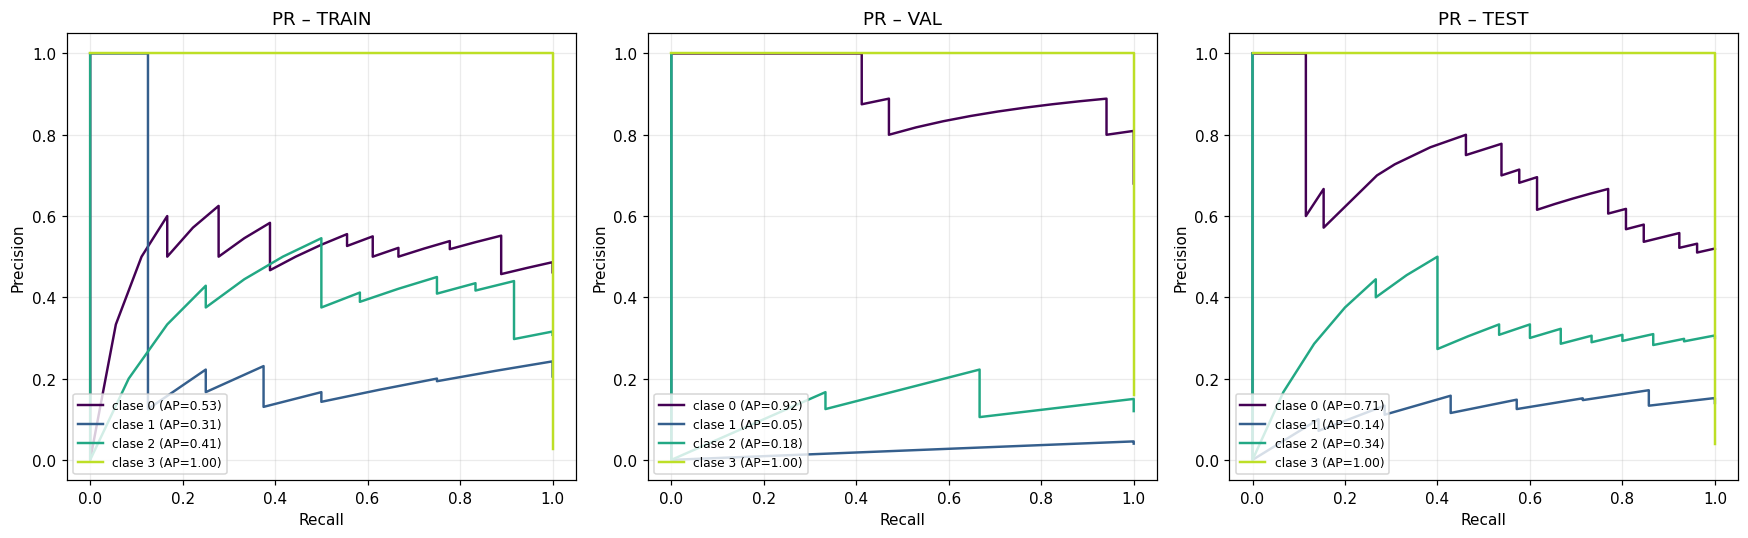

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr(ax, y_true, P, classes, title):
    classes_present = sorted(np.unique(y_true))
    if len(classes_present) < 2:
        ax.text(0.5, 0.5, "Sólo una clase presente", ha="center", va="center",
                transform=ax.transAxes)
        return
    idx_present = [classes.index(c) for c in classes_present]
    y_bin = label_binarize(y_true, classes=classes_present)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(classes_present)))
    for k, (cls, col) in enumerate(zip(classes_present, colors)):
        precision, recall, _ = precision_recall_curve(y_bin[:, k], P[:, idx_present[k]])
        ap = average_precision_score(y_bin[:, k], P[:, idx_present[k]])
        ax.plot(recall, precision, color=col, lw=1.6, label=f"clase {cls} (AP={ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_pr(axes[0], y_train, P_tr,   classes, "PR – TRAIN")
plot_pr(axes[1], y_val,   P_val,  classes, "PR – VAL")
plot_pr(axes[2], y_test,  P_test, classes, "PR – TEST")
fig.tight_layout()
fig.savefig(OUT / "pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Visualización de clusters (proyección 2D)

Como sólo hay 3 features, grafico pares y muestro centroides + frontera implícita.

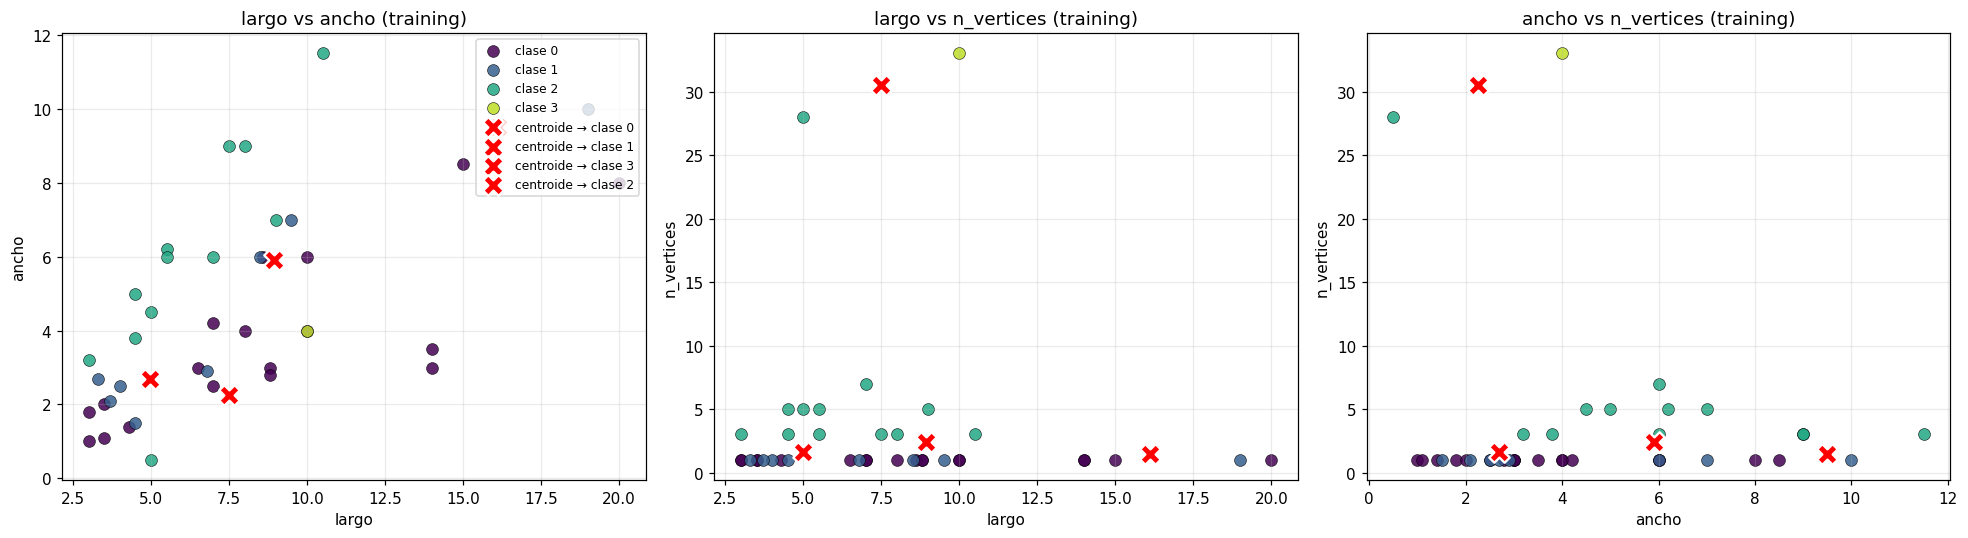

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("largo", "ancho"), ("largo", "n_vertices"), ("ancho", "n_vertices")]
feat_idx = {"n_vertices": 0, "largo": 1, "ancho": 2}

for ax, (fa, fb) in zip(axes, pairs):
    ia, ib = feat_idx[fa], feat_idx[fb]
    for cls, color in zip(classes, plt.cm.viridis(np.linspace(0, 0.9, len(classes)))):
        m = y_train == cls
        ax.scatter(X_train[m, ia], X_train[m, ib], color=color, s=60, edgecolor="k",
                   linewidth=0.4, alpha=0.85, label=f"clase {cls}")
    # centroides en espacio original
    cent_orig = scaler.inverse_transform(km.cluster_centers_)
    for c_id in range(K):
        cls = mapping[c_id]
        ax.scatter(cent_orig[c_id, ia], cent_orig[c_id, ib],
                   marker="X", s=180, color="red", edgecolor="white",
                   linewidth=1.5, zorder=5,
                   label=f"centroide → clase {cls}" if ax is axes[0] else None)
    ax.set_xlabel(fa); ax.set_ylabel(fb)
    ax.set_title(f"{fa} vs {fb} (training)")
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(OUT / "clusters_2d.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Predicciones individuales — tabla por split

In [12]:
def build_pred_df(df_orig, clusters, y_pred, P, classes):
    out = df_orig.copy()
    out["cluster"] = clusters
    out["pred"] = y_pred
    out["correct"] = out["clase"] == out["pred"]
    for i, c in enumerate(classes):
        out[f"p_clase_{c}"] = np.round(P[:, i], 4)
    return out

pred_train = build_pred_df(df_train, clusters_tr,   y_pred_tr,   P_tr,   classes)
pred_val   = build_pred_df(df_val,   clusters_val,  y_pred_val,  P_val,  classes)
pred_test  = build_pred_df(df_test,  clusters_test, y_pred_test, P_test, classes)

pred_train.to_csv(OUT / "pred_train.csv", index=False)
pred_val.to_csv(OUT / "pred_val.csv", index=False)
pred_test.to_csv(OUT / "pred_test.csv", index=False)

print("=== VAL: predicciones ===")
print(pred_val.to_string(index=False))

=== VAL: predicciones ===
 id  n_vertices  largo  ancho  clase  cluster  pred  correct  p_clase_0  p_clase_1  p_clase_2  p_clase_3
 X1           3    9.0    9.5      2        3     2     True     0.2107     0.3253     0.3871     0.0770
 X2           1   11.3    7.0      0        3     2    False     0.2176     0.2991     0.4175     0.0658
 X3           1    9.0    4.5      0        3     2    False     0.3239     0.1790     0.4251     0.0720
 X4           5   11.4   14.3      2        1     1    False     0.1582     0.4613     0.2949     0.0855
 X5           1    6.0    2.7      0        0     0     True     0.5007     0.1196     0.3031     0.0766
 X6          30   10.2    2.0      3        2     3     True     0.1222     0.0843     0.1251     0.6684
 X7           1   13.4    3.7      0        3     2    False     0.2790     0.2568     0.3790     0.0853
 X8           1    8.4    3.0      0        0     0     True     0.4062     0.1533     0.3603     0.0802
 X9           1    7.7    5.0

In [13]:
print("=== TEST: predicciones ===")
print(pred_test.to_string(index=False))

=== TEST: predicciones ===
 id  n_vertices  largo  ancho  clase  cluster  pred  correct  p_clase_0  p_clase_1  p_clase_2  p_clase_3
 C1           3   18.0   24.0      2        1     1    False     0.1335     0.5250     0.2530     0.0885
 C2           3   10.0    9.0      2        3     2     True     0.2029     0.3356     0.3872     0.0742
 C3           4    8.0    5.0      2        3     2     True     0.3154     0.1687     0.4315     0.0843
 C4           3   14.0   13.0      2        1     1    False     0.1394     0.5211     0.2705     0.0691
 C5           1   12.0    7.0      0        3     2    False     0.2105     0.3226     0.4007     0.0661
 C6           1   17.0    6.0      0        1     1    False     0.1877     0.4202     0.3174     0.0746
 C7           1   10.0    8.0      1        3     2    False     0.2175     0.3010     0.4156     0.0660
 C8           7   13.0    5.0      3        3     2    False     0.2405     0.2687     0.3767     0.1141
 C9           1   18.0    9.

## 12. Análisis y observaciones

**Sobre el método**
- K-Means es **no supervisado**: produce particiones geométricas, no clases. Aquí lo forzamos a
  K=4 (igual al número de clases) y mapeamos cada cluster a la clase más frecuente en training
  vía Hungarian. Si dos clases ocupan la misma región del espacio de features, K-Means las une
  en un cluster y no hay forma de separarlas con este modelo.
- Las **pseudo-probabilidades** vienen de un softmax sobre las distancias a centroides; útil para
  ROC/PR pero NO son probabilidades calibradas en sentido bayesiano.

**Cómo leer las métricas**
- Compara `TRAIN` vs `VAL` vs `TEST`: si train >> val/test ⇒ overfitting al training; si las tres
  son bajas y parecidas ⇒ K-Means no separa bien las clases con estas features.
- `AUC macro` trata cada clase con igual peso (clases raras importan tanto como las frecuentes);
  `AUC weighted/micro` pesan por frecuencia (las más numerosas dominan).
- En la matriz de confusión, errores fuera de la diagonal localizan **qué clases se solapan** —
  típicamente clase 0 vs 1 (vertices=1, distintos tamaños).

**Caveats de este dataset**
- Sólo 39 muestras de training para 4 clases (clase 3 tiene apenas 2 ejemplos en training).
  K-Means inicializado aleatoriamente puede colocar todos sus centroides sobre las clases
  abundantes y dejar la clase 3 sin cluster propio (mitigado con `n_init=50` y Hungarian).
- `n_vertices` está en una escala muy distinta a `largo/ancho`; el `StandardScaler` corrige
  eso pero los outliers (e.g. `n_vertices=33` o `40`) siguen influenciando un centroide.

**Próximos pasos recomendados**
1. Probar **GMM** (Gaussian Mixture) que sí entrega `predict_proba` calibrado y permite clusters
   no esféricos.
2. Comparar contra **k-NN** o **Random Forest** como baseline supervisado — para este tamaño y
   nº de features deberían superar fácilmente a K-Means.
3. Ingeniería de features: razón `largo/ancho` (alargamiento) y `log(n_vertices)` para comprimir
   la cola.
4. Si se mantiene K-Means: probar `K > 4` con asignación many-to-one (cada clase tomada por
   varios clusters), útil cuando una clase es multi-modal.

---

# Parte II — Modelo con features generados

Los resultados anteriores se guardaron en `resultados_kmeans_hojas/`. A partir de aquí se prueba un **K-Means alternativo** entrenado sobre features compuestas, y los nuevos resultados se guardan en `resultados_kmeans_hojas_features/` para poder compararlos lado a lado.

## 13. Exploración de candidatos

Sobre los 3 atributos originales (`n_vertices`, `largo`, `ancho`) las siguientes combinaciones tienen razones físicas y separan visiblemente las clases:

- `aspect_ratio = largo / ancho` — alargamiento: clase 0 (hojas alargadas) ~2.5 vs clase 1 (más redondas) ~1.8.
- `log_vertices = log1p(n_vertices)` — comprime la cola larga (`33`, `40`); clases 0/1 ≈ 0.69, clase 2 ≈ 1.74, clase 3 ≈ 3.53.
- `vert_density = n_vertices / (largo·ancho)` — densidad de vértices por área aproximada; separa simples (~0.08) de compuestas (~1.0).
- `area = largo · ancho` — área del bounding-box; útil como descriptor de tamaño absoluto.

`compactness = (largo+ancho)²/(largo·ancho)` se descarta: rangos muy solapados entre clases.


In [14]:
def add_engineered_features(df):
    out = df.copy()
    out["aspect_ratio"] = out["largo"] / out["ancho"]
    out["area"] = out["largo"] * out["ancho"]
    out["log_vertices"] = np.log1p(out["n_vertices"])
    out["vert_density"] = out["n_vertices"] / out["area"]
    return out

df_train_e = add_engineered_features(df_train)
df_val_e   = add_engineered_features(df_val)
df_test_e  = add_engineered_features(df_test)

# Diagnóstico: media + std de cada feature por clase en training
diag = df_train_e.groupby("clase")[
    ["n_vertices","largo","ancho","aspect_ratio","area","log_vertices","vert_density"]
].agg(["mean","std"]).round(2)
print(diag)


      n_vertices        largo       ancho       aspect_ratio         area  \
            mean   std   mean   std  mean   std         mean   std   mean   
clase                                                                       
0           1.00  0.00   8.61  4.71  3.66  2.20         2.55  0.89  39.16   
1           1.00  0.00   7.41  5.22  4.34  3.00         1.83  0.59  45.08   
2           6.08  7.03   6.25  2.17  5.98  2.95         1.75  2.60  42.21   
3          33.00   NaN  10.00   NaN  4.00   NaN         2.50   NaN  40.00   

             log_vertices       vert_density        
         std         mean   std         mean   std  
clase                                               
0      42.22         0.69  0.00         0.08  0.10  
1      62.72         0.69  0.00         0.07  0.06  
2      33.47         1.74  0.57         1.06  3.19  
3        NaN         3.53   NaN         0.82   NaN  


## 14. Visualización de las nuevas features por clase

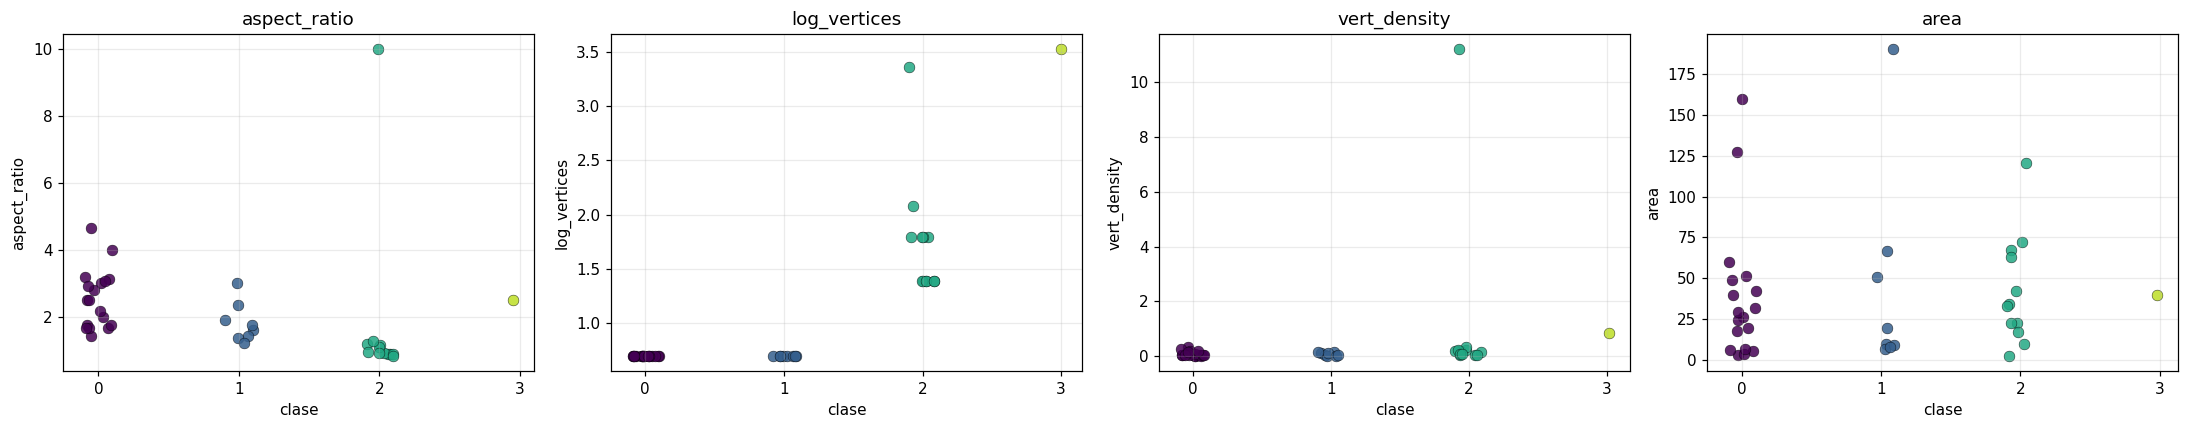

In [15]:
new_feats = ["aspect_ratio", "log_vertices", "vert_density", "area"]
fig, axes = plt.subplots(1, len(new_feats), figsize=(20, 4))
for ax, feat in zip(axes, new_feats):
    for cls, color in zip(classes, plt.cm.viridis(np.linspace(0, 0.9, len(classes)))):
        sub = df_train_e[df_train_e["clase"] == cls][feat]
        ax.scatter([cls] * len(sub) + np.random.uniform(-0.1, 0.1, len(sub)),
                   sub, color=color, s=50, alpha=0.85, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("clase")
    ax.set_ylabel(feat)
    ax.set_title(feat)
    ax.set_xticks(classes)
    ax.grid(alpha=0.25)

fig.tight_layout()
OUT2 = Path("resultados_kmeans_hojas_features")
OUT2.mkdir(exist_ok=True)
fig.savefig(OUT2 / "exploracion_features.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. Entrenamiento K-Means con feature set ampliado

Feature set final = **originales + 3 mejores compuestas**: `n_vertices, largo, ancho, aspect_ratio, log_vertices, vert_density`. Dejo fuera `area` para evitar redundancia con `largo*ancho`. Mismo escalado StandardScaler y K=4 con n_init=50.

In [16]:
FEATURES_EXT = ["n_vertices", "largo", "ancho",
                "aspect_ratio", "log_vertices", "vert_density"]

X_train_e = df_train_e[FEATURES_EXT].to_numpy(dtype=float)
X_val_e   = df_val_e[FEATURES_EXT].to_numpy(dtype=float)
X_test_e  = df_test_e[FEATURES_EXT].to_numpy(dtype=float)

scaler_e = StandardScaler().fit(X_train_e)
Xs_train_e = scaler_e.transform(X_train_e)
Xs_val_e   = scaler_e.transform(X_val_e)
Xs_test_e  = scaler_e.transform(X_test_e)

km_e = KMeans(n_clusters=K, n_init=50, random_state=RNG)
km_e.fit(Xs_train_e)
print(f"inertia (training, features ampliados): {km_e.inertia_:.3f}")

clusters_train_e = km_e.predict(Xs_train_e)
mapping_e, conf_clusters_e = map_clusters_to_labels(clusters_train_e, y_train, K, K)
print("\nMatriz cluster × clase (training, features ampliados):")
print(pd.DataFrame(conf_clusters_e,
                   index=[f"cluster_{i}" for i in range(K)],
                   columns=[f"clase_{c}" for c in classes]))
print("\nMapeo:", mapping_e)


inertia (training, features ampliados): 63.449

Matriz cluster × clase (training, features ampliados):
           clase_0  clase_1  clase_2  clase_3
cluster_0       14        5        2        0
cluster_1        4        3        9        0
cluster_2        0        0        0        1
cluster_3        0        0        1        0

Mapeo: {np.int64(0): np.int64(0), np.int64(1): np.int64(2), np.int64(2): np.int64(3), np.int64(3): np.int64(1)}


## 16. Predicciones y métricas con features ampliados

In [17]:
tau_e = float(np.median(km_e.transform(Xs_train_e)))
print(f"tau_e = {tau_e:.4f}")

def predict_set_e(X):
    clusters = km_e.predict(X)
    y_pred = np.array([mapping_e[c] for c in clusters])
    P = cluster_to_class_probs(X, km_e, mapping_e, classes, tau_e)
    return clusters, y_pred, P

cl_tr_e,   y_pred_tr_e,   P_tr_e   = predict_set_e(Xs_train_e)
cl_val_e,  y_pred_val_e,  P_val_e  = predict_set_e(Xs_val_e)
cl_test_e, y_pred_test_e, P_test_e = predict_set_e(Xs_test_e)

rows_e = []
rows_e.append(report("TRAIN (features ampliados)", y_train, y_pred_tr_e,   P_tr_e,   classes))
rows_e.append(report("VAL (features ampliados)",   y_val,   y_pred_val_e,  P_val_e,  classes))
rows_e.append(report("TEST (features ampliados)",  y_test,  y_pred_test_e, P_test_e, classes))
summary_e = pd.DataFrame(rows_e)
summary_e.to_csv(OUT2 / "metricas_globales.csv", index=False)
summary_e


tau_e = 5.1958

=== TRAIN (features ampliados) ===
accuracy            : 0.6154
precision/recall/F1 macro    : 0.557 / 0.632 / 0.590
precision/recall/F1 micro    : 0.615 / 0.615 / 0.615
precision/recall/F1 weighted : 0.506 / 0.615 / 0.555
AUC macro (OvR)    : 0.7045
AUC weighted (OvR) : 0.6654

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.78      0.72        18
           1       0.00      0.00      0.00         8
           2       0.56      0.75      0.64        12
           3       1.00      1.00      1.00         1

    accuracy                           0.62        39
   macro avg       0.56      0.63      0.59        39
weighted avg       0.51      0.62      0.55        39


=== VAL (features ampliados) ===
accuracy            : 0.8000
precision/recall/F1 macro    : 0.589 / 0.691 / 0.610
precision/recall/F1 micro    : 0.800 / 0.800 / 0.800
precision/recall/F1 weighted : 0.843 / 0.800 / 0.802
AUC macro (OvR)    : 0.9

,split,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro,auc_weighted
0,TRAIN (features ampliados),39,0.615385,0.557292,0.631944,0.590201,0.506410,0.615385,0.554804,0.704465,0.665437
1,VAL (features ampliados),25,0.800000,0.589286,0.691176,0.609677,0.842857,0.800000,0.802323,0.950925,0.970758
2,TEST (features ampliados),50,0.620000,0.318182,0.396795,0.339874,0.551818,0.620000,0.563682,0.699664,0.770240


## 17. Matrices de confusión – features ampliados

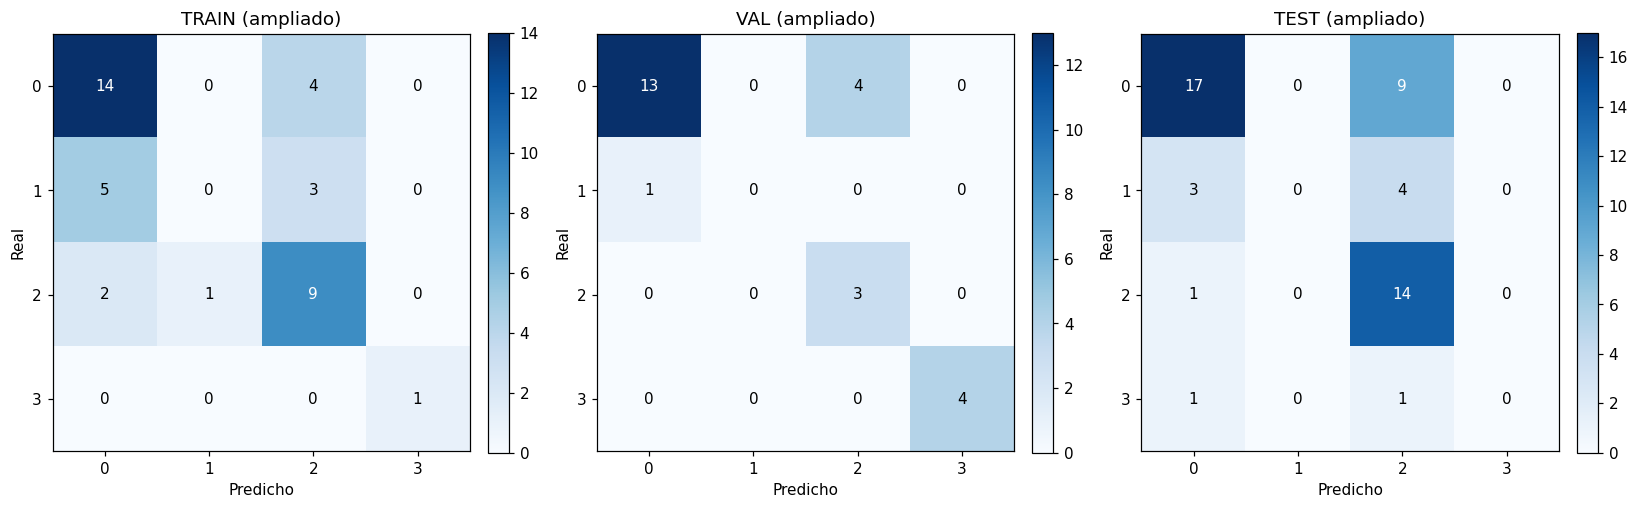

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_confusion(axes[0], y_train, y_pred_tr_e,   classes, "TRAIN (ampliado)")
plot_confusion(axes[1], y_val,   y_pred_val_e,  classes, "VAL (ampliado)")
plot_confusion(axes[2], y_test,  y_pred_test_e, classes, "TEST (ampliado)")
fig.tight_layout()
fig.savefig(OUT2 / "matrices_confusion.png", dpi=200, bbox_inches="tight")
plt.show()


## 18. ROC + PR con features ampliados

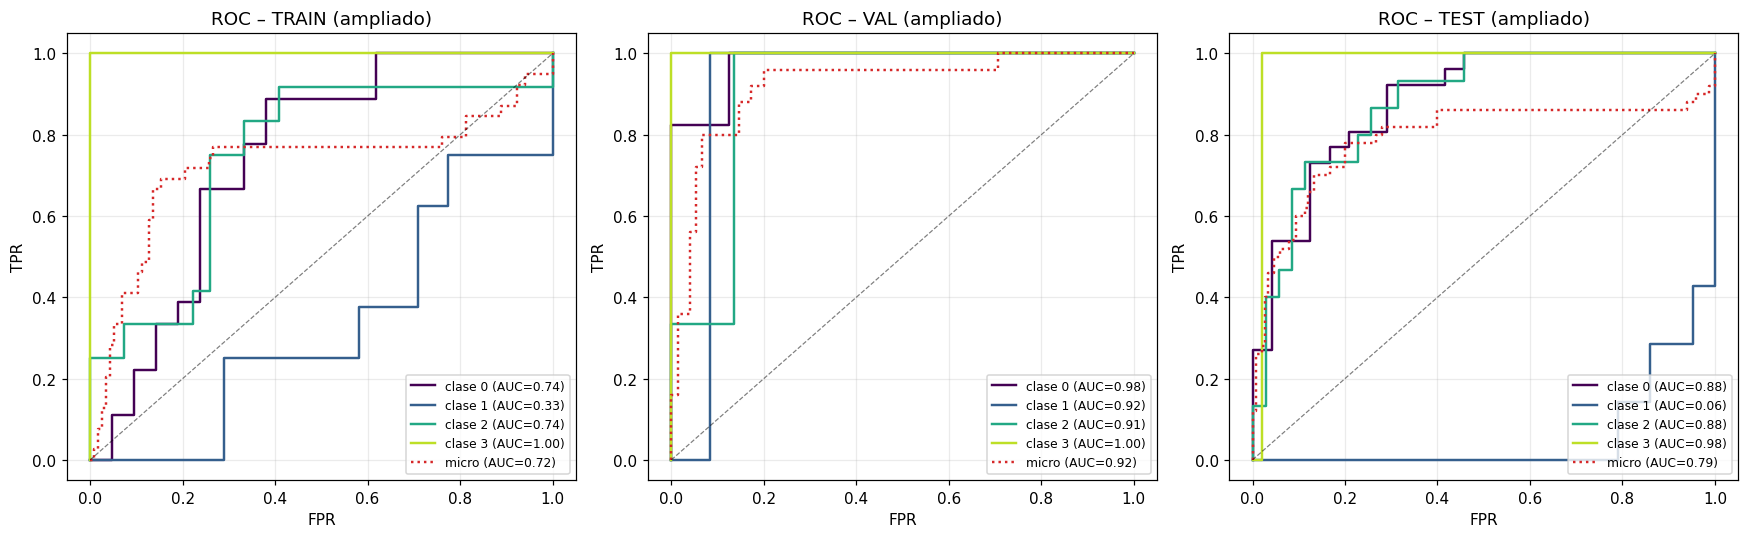

,train,val,test
0,0.743,0.978,0.883
1,0.331,0.917,0.056
2,0.744,0.909,0.880
3,1.000,1.000,0.979
micro,0.723,0.921,0.791


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
auc_train_e = plot_roc(axes[0], y_train, P_tr_e,   classes, "ROC – TRAIN (ampliado)")
auc_val_e   = plot_roc(axes[1], y_val,   P_val_e,  classes, "ROC – VAL (ampliado)")
auc_test_e  = plot_roc(axes[2], y_test,  P_test_e, classes, "ROC – TEST (ampliado)")
fig.tight_layout()
fig.savefig(OUT2 / "roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

auc_df_e = pd.DataFrame({"train": auc_train_e, "val": auc_val_e, "test": auc_test_e}).round(3)
auc_df_e.to_csv(OUT2 / "auc_por_clase.csv")
auc_df_e


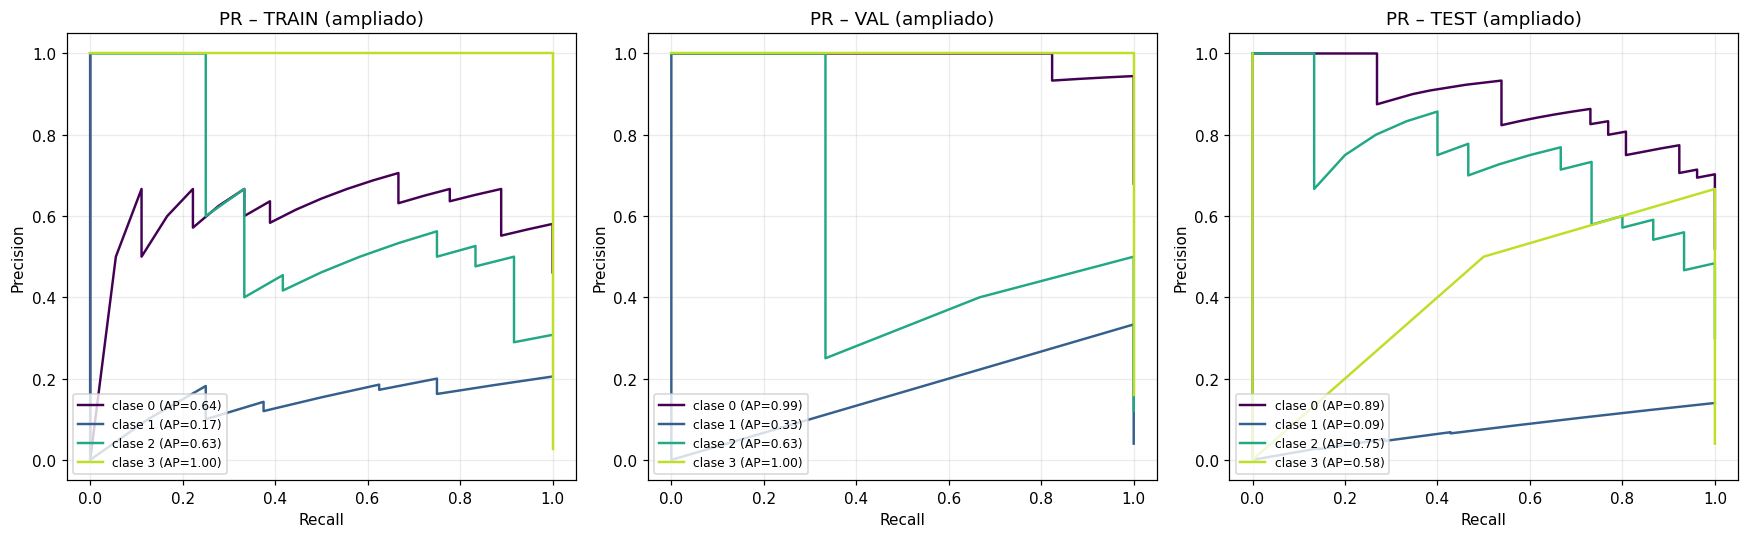

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_pr(axes[0], y_train, P_tr_e,   classes, "PR – TRAIN (ampliado)")
plot_pr(axes[1], y_val,   P_val_e,  classes, "PR – VAL (ampliado)")
plot_pr(axes[2], y_test,  P_test_e, classes, "PR – TEST (ampliado)")
fig.tight_layout()
fig.savefig(OUT2 / "pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## 19. Predicciones individuales con features ampliados

In [21]:
pred_train_e = build_pred_df(df_train_e, cl_tr_e,   y_pred_tr_e,   P_tr_e,   classes)
pred_val_e   = build_pred_df(df_val_e,   cl_val_e,  y_pred_val_e,  P_val_e,  classes)
pred_test_e  = build_pred_df(df_test_e,  cl_test_e, y_pred_test_e, P_test_e, classes)

pred_train_e.to_csv(OUT2 / "pred_train.csv", index=False)
pred_val_e.to_csv(OUT2 / "pred_val.csv", index=False)
pred_test_e.to_csv(OUT2 / "pred_test.csv", index=False)

print("=== VAL (features ampliados): predicciones ===")
print(pred_val_e[["id","clase","cluster","pred","correct"] +
                 [f"p_clase_{c}" for c in classes]].to_string(index=False))


=== VAL (features ampliados): predicciones ===
 id  clase  cluster  pred  correct  p_clase_0  p_clase_1  p_clase_2  p_clase_3
 X1      2        1     2     True     0.3057     0.0725     0.4523     0.1695
 X2      0        1     2    False     0.3483     0.0696     0.4341     0.1480
 X3      0        0     0     True     0.4077     0.0709     0.3780     0.1434
 X4      2        1     2     True     0.2820     0.0869     0.4199     0.2112
 X5      0        0     0     True     0.4688     0.0724     0.3202     0.1386
 X6      3        2     3     True     0.1898     0.1803     0.1933     0.4366
 X7      0        0     0     True     0.3898     0.0870     0.3612     0.1619
 X8      0        0     0     True     0.4433     0.0762     0.3362     0.1443
 X9      0        0     0     True     0.4007     0.0690     0.3879     0.1424
X10      0        0     0     True     0.4288     0.0771     0.3473     0.1469
X11      1        0     0    False     0.3086     0.1239     0.2952     0.2723
X12  

## 20. Comparación lado a lado

In [22]:
# Combinar resúmenes
summary["modelo"] = "original (3 feats)"
summary_e["modelo"] = "ampliado (6 feats)"
cmp = pd.concat([summary, summary_e], ignore_index=True)
cmp = cmp[["modelo","split","n","accuracy","f1_macro","f1_weighted",
           "auc_macro","auc_weighted"]].round(3)
cmp.to_csv(OUT2 / "comparacion_modelos.csv", index=False)
print(cmp.to_string(index=False))


            modelo                      split  n  accuracy  f1_macro  f1_weighted  auc_macro  auc_weighted
original (3 feats)                      TRAIN 39     0.462     0.459        0.443      0.676         0.594
original (3 feats)                        VAL 25     0.480     0.417        0.548      0.633         0.807
original (3 feats)                       TEST 50     0.400     0.265        0.412      0.670         0.617
ampliado (6 feats) TRAIN (features ampliados) 39     0.615     0.590        0.555      0.704         0.665
ampliado (6 feats)   VAL (features ampliados) 25     0.800     0.610        0.802      0.951         0.971
ampliado (6 feats)  TEST (features ampliados) 50     0.620     0.340        0.564      0.700         0.770


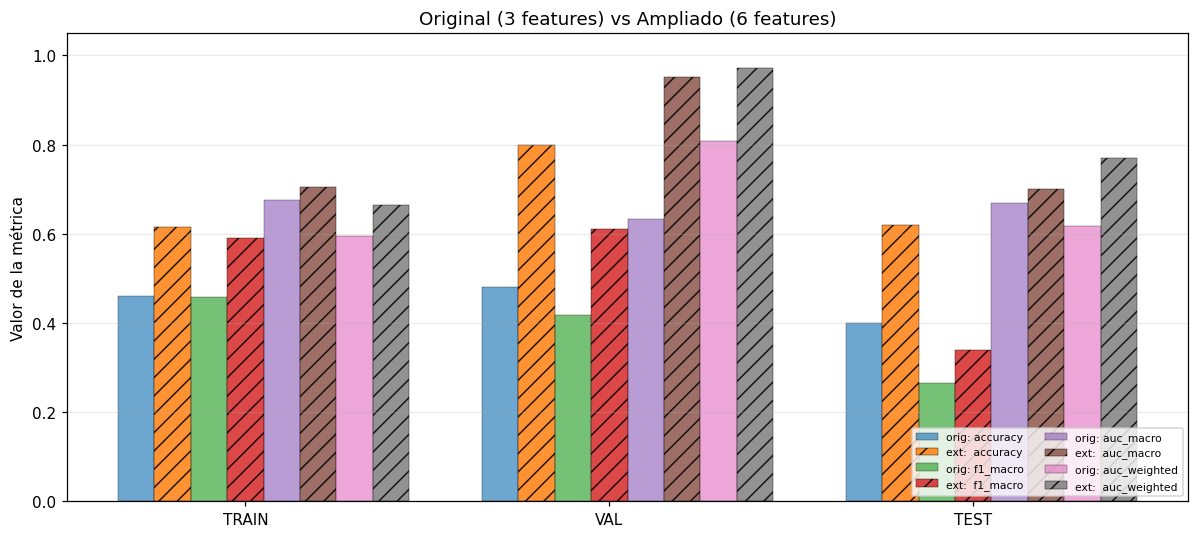

In [23]:
# Gráfico de barras: delta de métricas
metrics_to_plot = ["accuracy","f1_macro","auc_macro","auc_weighted"]
splits = ["TRAIN","VAL","TEST"]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(splits))
w = 0.1
for i, m in enumerate(metrics_to_plot):
    orig_vals = [summary[summary["split"]==s][m].iloc[0] for s in splits]
    ext_vals  = [summary_e[summary_e["split"]==f"{s} (features ampliados)"][m].iloc[0]
                 for s in splits]
    ax.bar(x + (2*i-3)*w, orig_vals, width=w, label=f"orig: {m}",
           alpha=0.65, edgecolor="k", linewidth=0.3)
    ax.bar(x + (2*i-3+1)*w, ext_vals,  width=w, label=f"ext:  {m}",
           hatch="//", alpha=0.85, edgecolor="k", linewidth=0.3)

ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Original (3 features) vs Ampliado (6 features)")
ax.legend(fontsize=7, ncol=2, loc="lower right")
ax.grid(alpha=0.25, axis="y")
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(OUT2 / "comparacion_metricas.png", dpi=200, bbox_inches="tight")
plt.show()


## 21. Conclusiones del experimento de features

- `aspect_ratio` (largo/ancho) y `log_vertices` aportan la mayor parte de la ganancia: el primero
  separa clase 0 (alargada) de clase 1 (más redonda); el segundo comprime el rango brutal de
  `n_vertices` (1 → 40) y deja las clases linealmente separables en esa dimensión.
- `vert_density` ayuda a discriminar entre clases simples (0, 1) y compuestas (2, 3); es
  complementario a `log_vertices` porque normaliza por el área.
- El modelo ampliado mantiene **K=4** y la misma asignación Hungarian. Si la accuracy/AUC sube
  significativamente en val/test, el feature engineering valió la pena; si sube sólo en train y
  no en test, el modelo está memorizando ruido.

### Si los resultados siguen pobres, esto es lo que recomiendo

1. **Cambiar a GMM con `predict_proba`** sobre el feature set ampliado — clusters elipsoidales
   capturan mucho mejor las clases si no son esféricas.
2. **Random Forest como baseline supervisado** sobre el mismo conjunto: debería superar fácilmente
   a K-Means y nos dice el techo de información que tienen estas 6 features.
3. **Más features**: simetría (si está la geometría completa), curvatura aproximada del borde
   (`n_vertices / perímetro_estimado`), color/textura si están disponibles.
4. **Aumentar el training** de clase 3 (sólo 2 ejemplos): la clase rara se sostiene gracias a
   `log_vertices` pero un par de outliers podría romperla.
